## Data visulization

These datas are downloaded from **U.S. Department of Energy**, **Atlas Public Policy**, **U.S. Census Bureau**.

We collects EV car registered information, Charge port data and population data in each states.

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [47]:
path_eff="Raw_Data/EV_efficiency_csv.csv"
path_data="Raw_Data/datas_by_states.csv"
path_manu="Raw_Data/VIN_Decoder.csv"

df_eff = pd.read_csv(path_eff)
df_data = pd.read_csv(path_data)
df_manu = pd.read_csv(path_manu)


### Registration number of EV car and other variables

In [48]:
print(f"Number of states in df_data: {df_data.shape[0]}")

Number of states in df_data: 51


In [49]:
df_data.columns

Index(['State', 'Registration Count', 'Mean households income', 'Population',
       'Population Density', 'Mean travel time to work', 'URBAN POP',
       'URBAN POP_PCT', 'EV Charging Station', 'EV Charging Port'],
      dtype='object')

**Top 5 States: Registration Counts, Polulation, Mean households income.**

**Regisration Counts**: 1. California, 2. Florida, 3. Texas, 4. Washington, 5. New Jersey

**Population**: 1. California, 2. Texas, 3. Florida, 4. New York, 5. Pennsylvania

**Mean households income**: 1. District of Columbia, 2. Massachusetts, 3. Maryland, 4. Utah, 5. New Hampshire

**Population Density**:1. District of Columbia, 2. New Jersey , 3. Rhode Island, 4. Massachusetts, 5.Massachusetts

**Mean Travel Time to Work**:1. New York, 2. Maryland, 3. New Jersey, 4. District of Columbia, 5. Massachusetts

**Urban Population**:1. California, 2.Texas, 3. Florida, 4.  New York, 5.Illinois

**Urban Population Percentage**:1. District of Columbia, 2.California, 3. Nevada, 4.  New Jersey, 5.Florida


In [50]:
# Display top 5 states for each column
print("Top 5 States by Registration Count:")
print(df_data[['State', 'Registration Count']].sort_values(by="Registration Count", ascending=False).head(5))
print("\n")

print("Top 5 States by Population:")
print(df_data[['State', 'Population']].sort_values(by="Population", ascending=False).head(5))
print("\n")

print("Top 5 States by Mean Households Income:")
print(df_data[['State', 'Mean households income']].sort_values(by="Mean households income", ascending=False).head(5))
print("\n")

print("Top 5 States by Population Density:")
print(df_data[['State', 'Population Density']].sort_values(by="Population Density", ascending=False).head(5))
print("\n")

print("Top 5 States by Mean Travel Time to Work:")
print(df_data[['State', 'Mean travel time to work']].sort_values(by="Mean travel time to work", ascending=False).head(5))
print("\n")

print("Top 5 States by Urban Population:")
print(df_data[['State', 'URBAN POP']].sort_values(by="URBAN POP", ascending=False).head(5))
print("\n")

print("Top 5 States by Urban Population Percentage:")
print(df_data[['State', 'URBAN POP_PCT']].sort_values(by="URBAN POP_PCT", ascending=False).head(5))

Top 5 States by Registration Count:
         State  Registration Count
4   California             1256646
9      Florida              254878
43       Texas              230125
47  Washington              152101
30  New Jersey              134753


Top 5 States by Population:
           State  Population
4     California    39181667
43         Texas    30719247
9        Florida    22929248
32      New York    19786543
38  Pennsylvania    13009406


Top 5 States by Mean Households Income:
                   State  Mean households income
8   District of Columbia                  111000
21         Massachusetts                  106500
20              Maryland                  102000
44                  Utah                  101200
29         New Hampshire                   98780


Top 5 States by Population Density:
                   State  Population Density
8   District of Columbia            11130.69
30            New Jersey             1263.37
39          Rhode Island             1059

The correlation of Registration Count with different valuable
EV Charging Port            0.976260
EV Charging Station         0.973132
URBAN POP                   0.853273
Population                  0.804287
URBAN POP_PCT               0.351822
Mean travel time to work    0.329982
Mean households income      0.137548
Population Density         -0.028985
Name: Registration Count, dtype: float64


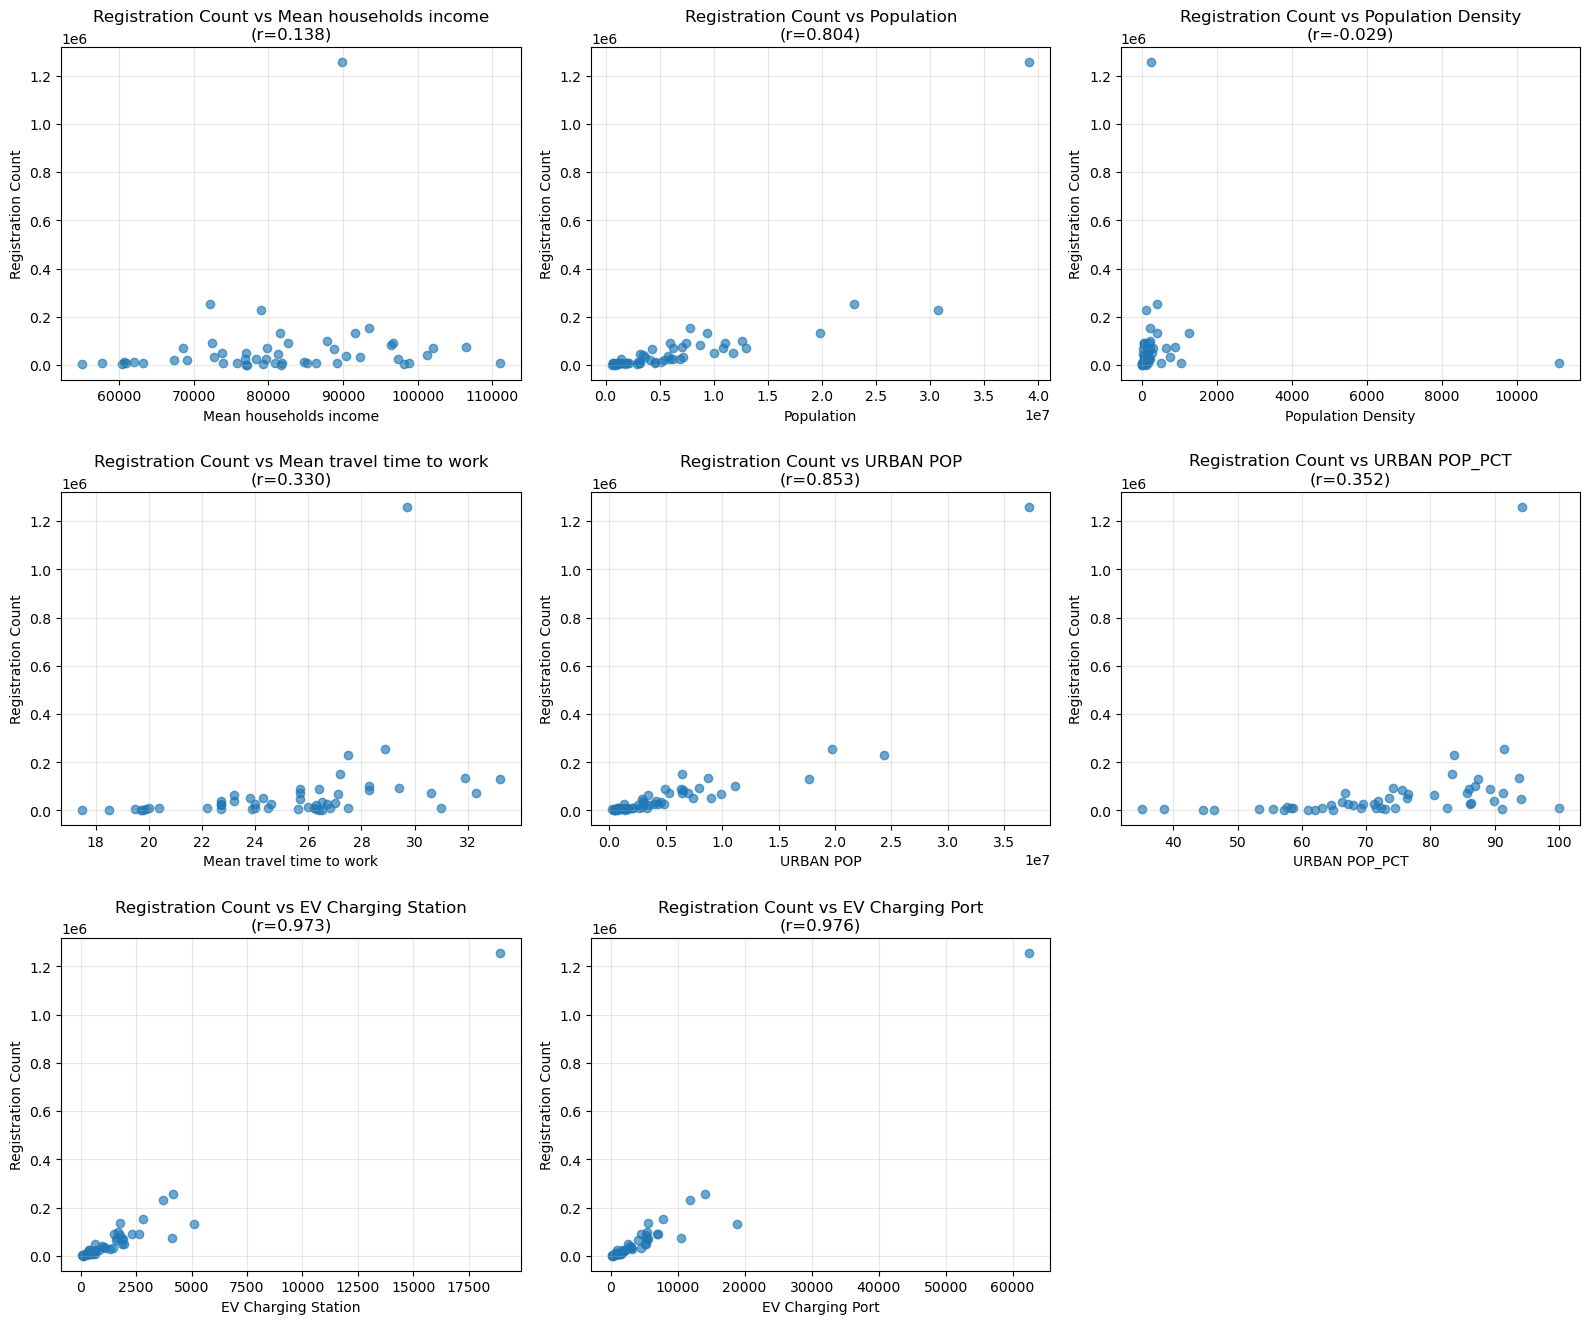

In [51]:
numeric_cols = df_data.select_dtypes(include=[np.number]).columns.tolist()
features = [c for c in numeric_cols if c != "Registration Count"]

correlation_matrix = df_data[["Registration Count"] + features].corr()
corr_with_reg = correlation_matrix["Registration Count"].drop("Registration Count").sort_values(ascending=False)

print("The correlation of Registration Count with different valuable")
print(corr_with_reg)

n = len(features)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(features):
    axes[i].scatter(df_data[col], df_data["Registration Count"], alpha=0.65)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Registration Count")
    axes[i].set_title(f"Registration Count vs {col}\n(r={corr_with_reg[col]:.3f})")
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


According to the data, **Registration Count** has high correlation with **Urban population** and **Population**. 

#### Efficiency of different type of EV car

In [52]:
df_eff.head()

,Vehicle Size Class,City,Highway,Combined,BEV Registrations,Portion of BEV Registrations
0,Overall,5.1,3.6,4.4,"3,726,000",100%
1,Subcompact Cars,6.0,3.5,4.8,"56,000",2%
2,Compact Cars,2.7,2.3,2.6,"163,000",4%
3,Midsize Cars,5.3,3.5,4.4,"1,065,000",29%
4,Large Cars,4.3,3.1,3.7,"274,000",7%


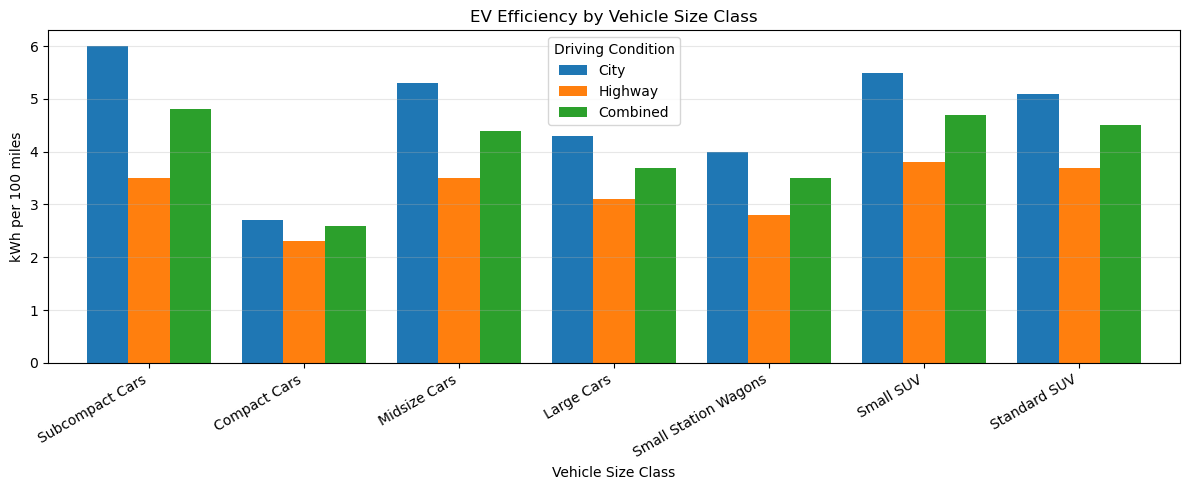

In [53]:
plot_eff = df_eff[df_eff["Vehicle Size Class"] != "Overall"].copy()

ax = plot_eff.set_index("Vehicle Size Class")[["City", "Highway", "Combined"]].plot(
    kind="bar",
    figsize=(12, 5),
    width=0.8
)
ax.set_title("EV Efficiency by Vehicle Size Class")
ax.set_xlabel("Vehicle Size Class")
ax.set_ylabel("kWh per 100 miles")
ax.legend(title="Driving Condition")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

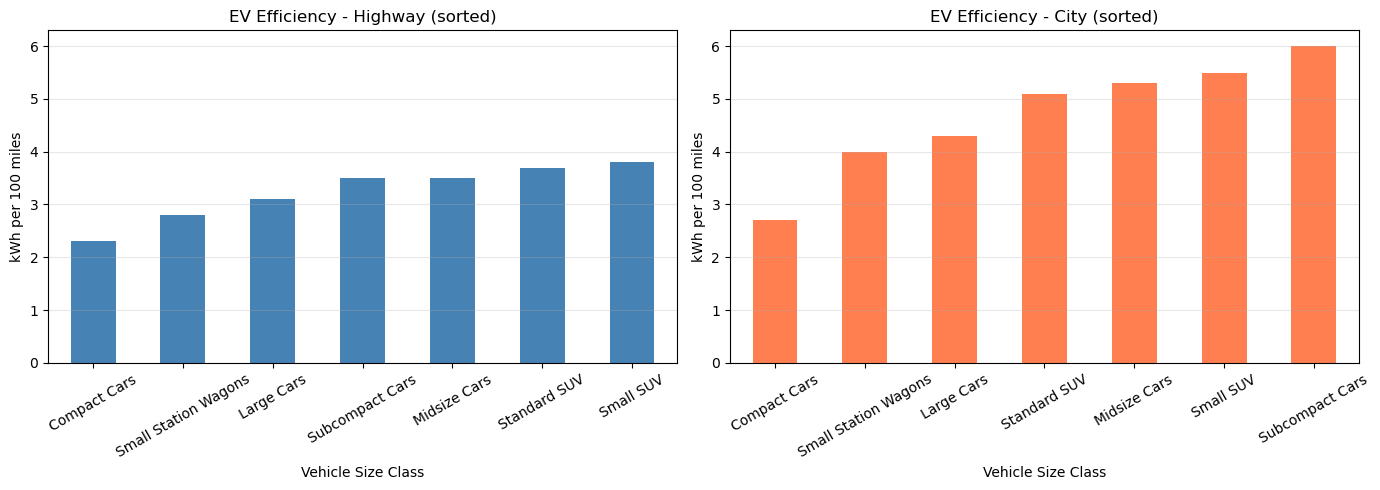

In [54]:
plot_eff = df_eff[df_eff["Vehicle Size Class"] != "Overall"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Highway plot (sorted ascending - smallest to largest)
plot_eff.sort_values("Highway", ascending=True).set_index("Vehicle Size Class")["Highway"].plot(
    kind="bar",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("EV Efficiency - Highway (sorted)")
axes[0].set_xlabel("Vehicle Size Class")
axes[0].set_ylabel("kWh per 100 miles")
axes[0].set_ylim(0, 6.3)
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis='x', rotation=30)

# City plot (sorted ascending - smallest to largest)
plot_eff.sort_values("City", ascending=True).set_index("Vehicle Size Class")["City"].plot(
    kind="bar",
    ax=axes[1],
    color="coral"
)
axes[1].set_title("EV Efficiency - City (sorted)")
axes[1].set_xlabel("Vehicle Size Class")
axes[1].set_ylabel("kWh per 100 miles")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

City driving shows higher energy consumption overall across all segments compared to highway. The spread between categories is wider than on the highway (around 3 kWh/100 miles difference), showing that stop‑and‑go driving amplifies the inefficiency of larger vehicles.Smaller vehicles stay relatively consistent across conditions, showing that lighter EVs are better adapted to urban use. If most driving occurs on highways, the efficiency difference between vehicle sizes is smaller, so users may have more flexibility to choose a vehicle size based on their preferences.    

#### VIN()

In [55]:
df_manu.head()

,VIN Prefix,VIN Model Year,Vehicle Name,Technology,Make,Model,Model Year,Date Added,Date Updated,VIN_Key,Vehicle Type,Vehicle Subtype,Vehicle GVWR Class,Vehicle GVWR Category,Vehicle Characteristics Source,Error Code,Error Text
0,11VG815E,J,KALMAR INDUSTRIES LLC OTTAWA T2E,BEV,KALMAR INDUSTRIES LLC,OTTAWA T2E,2018.0,2023-03-15,2023-03-15,11VG815EJ,Truck,Tractor,NaN,NaN,NHTSA,"4,6,14","4 - VIN corrected, error in one position only ..."
1,11VG815E,K,KALMAR INDUSTRIES LLC OTTAWA T2E,BEV,KALMAR INDUSTRIES LLC,OTTAWA T2E,2019.0,2023-03-15,2023-03-15,11VG815EK,Truck,Tractor,8,Heavy-Duty Vehicle (Class 7-8),NHTSA,6,6 - Incomplete VIN
2,11VG815E,L,KALMAR INDUSTRIES LLC OTTAWA T2E,BEV,KALMAR INDUSTRIES LLC,OTTAWA T2E,2020.0,2023-03-15,2023-03-15,11VG815EL,Truck,Tractor,8,Heavy-Duty Vehicle (Class 7-8),NHTSA,6,6 - Incomplete VIN
3,11VG815E,M,KALMAR INDUSTRIES LLC OTTAWA T2E,BEV,KALMAR INDUSTRIES LLC,OTTAWA T2E,2021.0,2023-03-15,2023-03-15,11VG815EM,Truck,Tractor,8,Heavy-Duty Vehicle (Class 7-8),NHTSA,6,6 - Incomplete VIN
4,11VG815E,N,KALMAR INDUSTRIES LLC OTTAWA T2E,BEV,KALMAR INDUSTRIES LLC,OTTAWA T2E,2022.0,2023-03-15,2023-03-15,11VG815EN,Truck,Tractor,8,Heavy-Duty Vehicle (Class 7-8),NHTSA,6,6 - Incomplete VIN


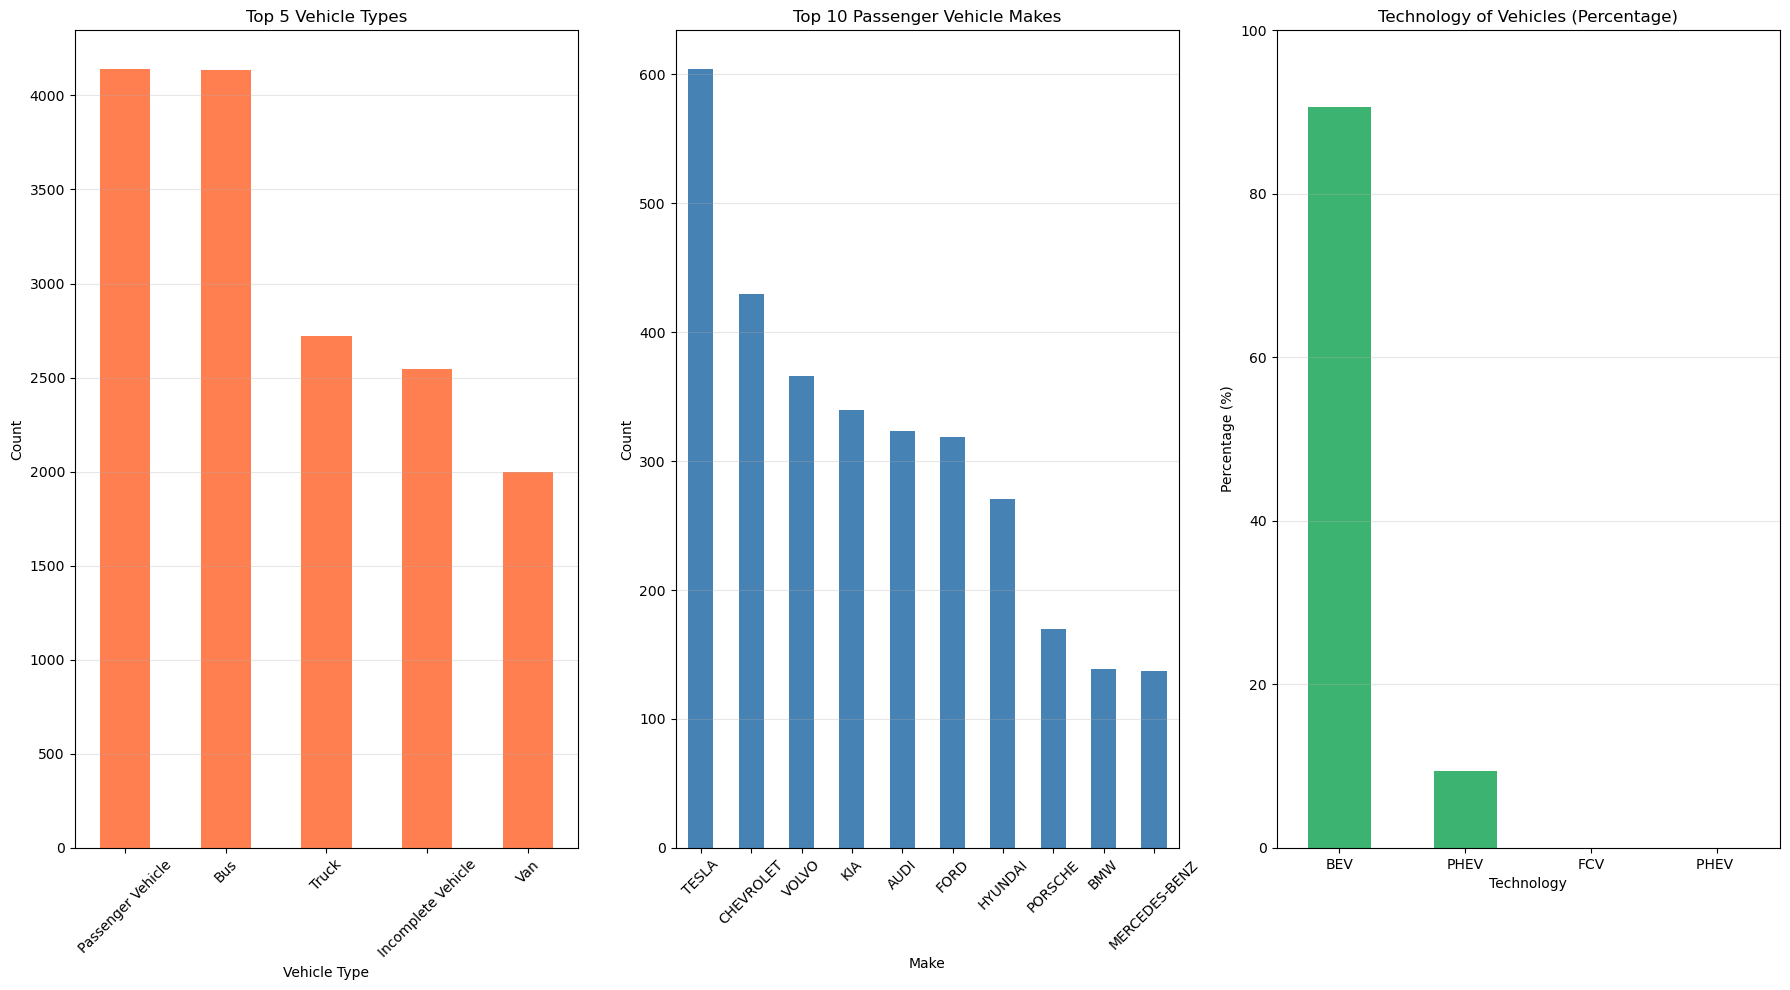

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10))

# 1. Market share by vehicle (Make)
df_manu['Vehicle Type'].value_counts().head(5).plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Top 5 Vehicle Types')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)


df_manu[df_manu['Vehicle Type'].str.contains('Passenger', case=False, na=False)]['Make'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Passenger Vehicle Makes')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

(df_manu['Technology'].value_counts(normalize=True) * 100).plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Technology of Vehicles (Percentage)')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_ylim(0, 100)
axes[2].grid(axis='y', alpha=0.3)
axes[2].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.show()

This distribution suggests that the dataset covers a broad range of vehicle categories, but is primarily driven by passenger vehicles, consistent with typical registration or sales data. In passenger vehicle,Tesla is by far the most common make, with a count over 600—significantly higher than all other brands.Chevrolet, Toyota, and Nissan follow, but with noticeably lower counts, indicating that the market is dominated by a few high‑volume manufacturers.The technology landscape reveals a strong shift toward fully electric drivetrains, with PHEVs and alternative technologies playing a much smaller role.

### Charge port

In [57]:
df_data.columns

Index(['State', 'Registration Count', 'Mean households income', 'Population',
       'Population Density', 'Mean travel time to work', 'URBAN POP',
       'URBAN POP_PCT', 'EV Charging Station', 'EV Charging Port'],
      dtype='object')

The correlation of EV Charging Station with other variables:
Registration Count          0.973132
URBAN POP                   0.882180
Population                  0.836880
Mean travel time to work    0.405169
URBAN POP_PCT               0.390349
Mean households income      0.174715
Population Density         -0.031656
Name: EV Charging Station, dtype: float64




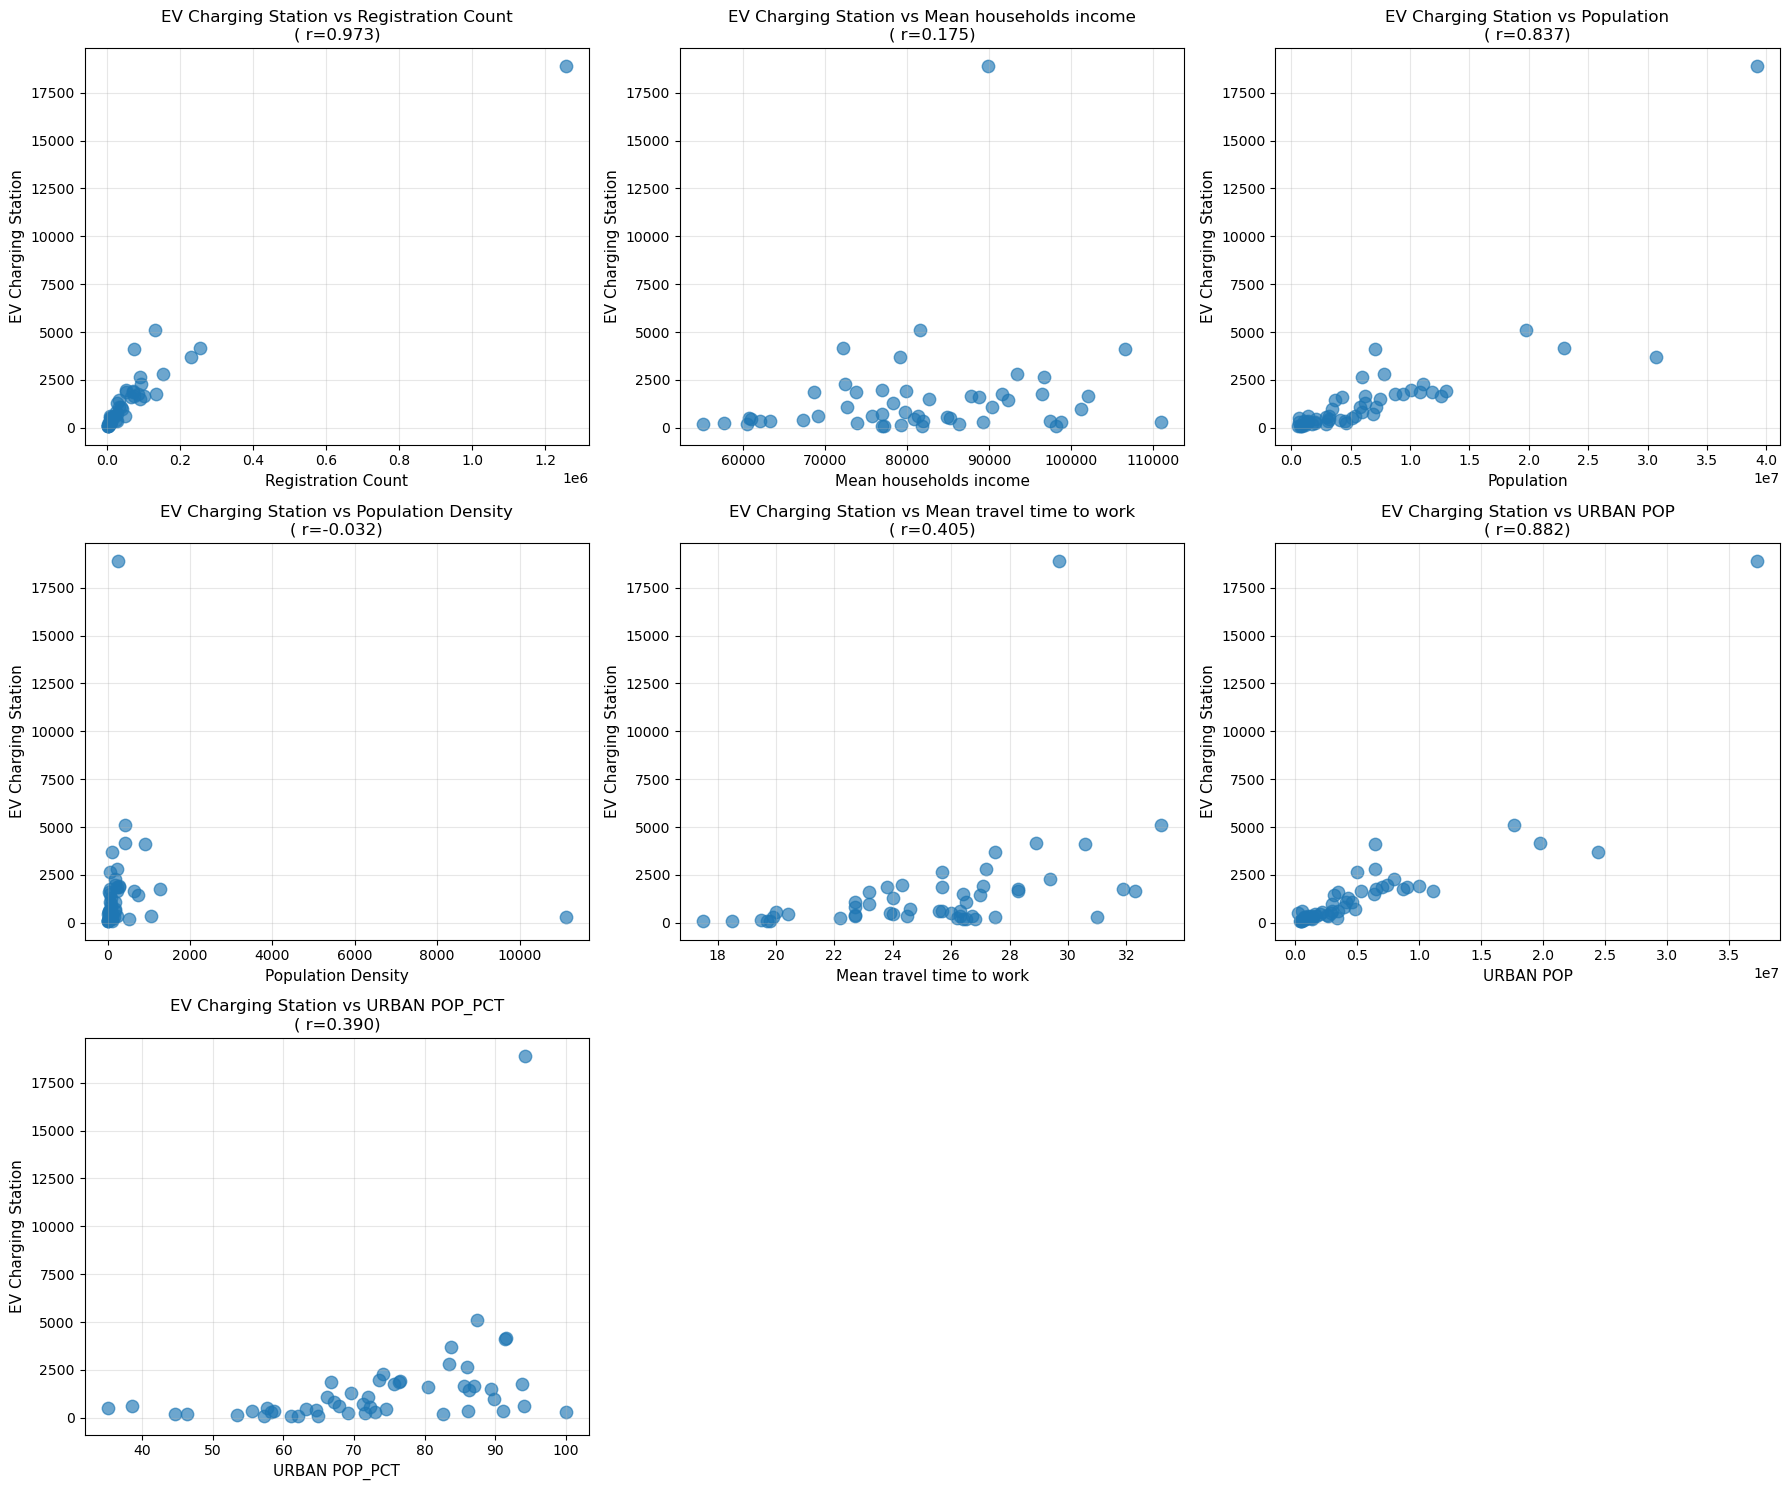

In [60]:
numeric_cols = df_data.select_dtypes(include=[np.number]).columns.tolist()
charging_cols = [c for c in numeric_cols if c not in ["EV Charging Port", "EV Charging Station"]]
correlation_charging = df_data[["EV Charging Station"] + charging_cols].corr()
corr_charging_with_reg = correlation_charging["EV Charging Station"].drop("EV Charging Station").sort_values(ascending=False)

print("The correlation of EV Charging Station with other variables:")
print(corr_charging_with_reg)
print("\n")

# 創建分布圖
n_vars = len(charging_cols)
ncols = 3
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(charging_cols):
    axes[i].scatter(df_data[col], df_data["EV Charging Station"], alpha=0.65, s=80)
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel("EV Charging Station", fontsize=11)
    axes[i].set_title(f"EV Charging Station vs {col}\n( r={corr_charging_with_reg[col]:.3f})", fontsize=12)
    axes[i].grid(alpha=0.3)


for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


EV charging station has higher correlation with **Registration EV car number**, **Urban population** and **population**.